Loading composite similarity matrix from similarity_outputs/composite_similarity_matrix.csv...
  Matrix shape  : (615, 615)
  Distance range: [0.0078, 1.0000]

[Clustering] Ward linkage on 615×615 distance matrix...
  Cophenetic Correlation Coefficient (CCC) = 0.3034
  ⚠ Moderate fidelity — consider other linkages

[Cluster Validity] Testing K = 4 to 60...
  K= 10  sil=0.0602  WCSS=125.76
  K= 20  sil=0.0355  WCSS=116.59
  K= 30  sil=0.0328  WCSS=109.93
  K= 40  sil=0.0460  WCSS=104.73
  K= 50  sil=0.0338  WCSS=99.79
  K= 60  sil=0.0434  WCSS=95.44


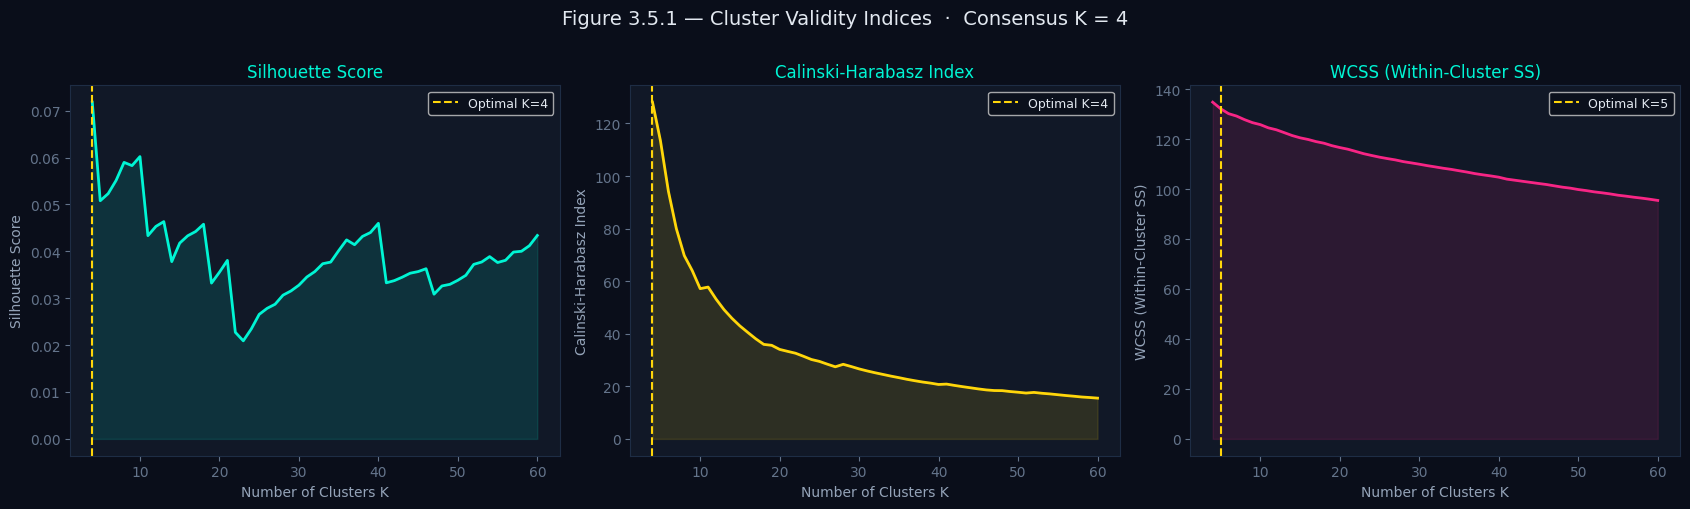


  Silhouette optimal K : 4
  CH optimal K         : 4
  WCSS elbow K         : 5
  ► Consensus K        : 4

► Using K = 4 for all downstream analysis.

  Loading return data for bootstrap (requires section_34 data)...
  Return pivot shape: (1823, 615)

[Bootstrap] Block bootstrap  B=200, block=20d, K=4
  Universe: 615 coins × 1823 days
  Bootstrap 50/200 complete
  Bootstrap 100/200 complete
  Bootstrap 150/200 complete
  Bootstrap 200/200 complete
  ✓ Bootstrap complete.
  Co-clustering freq range: [0.000, 1.000]
  Pairs with freq ≥ 0.80   : 14.1%


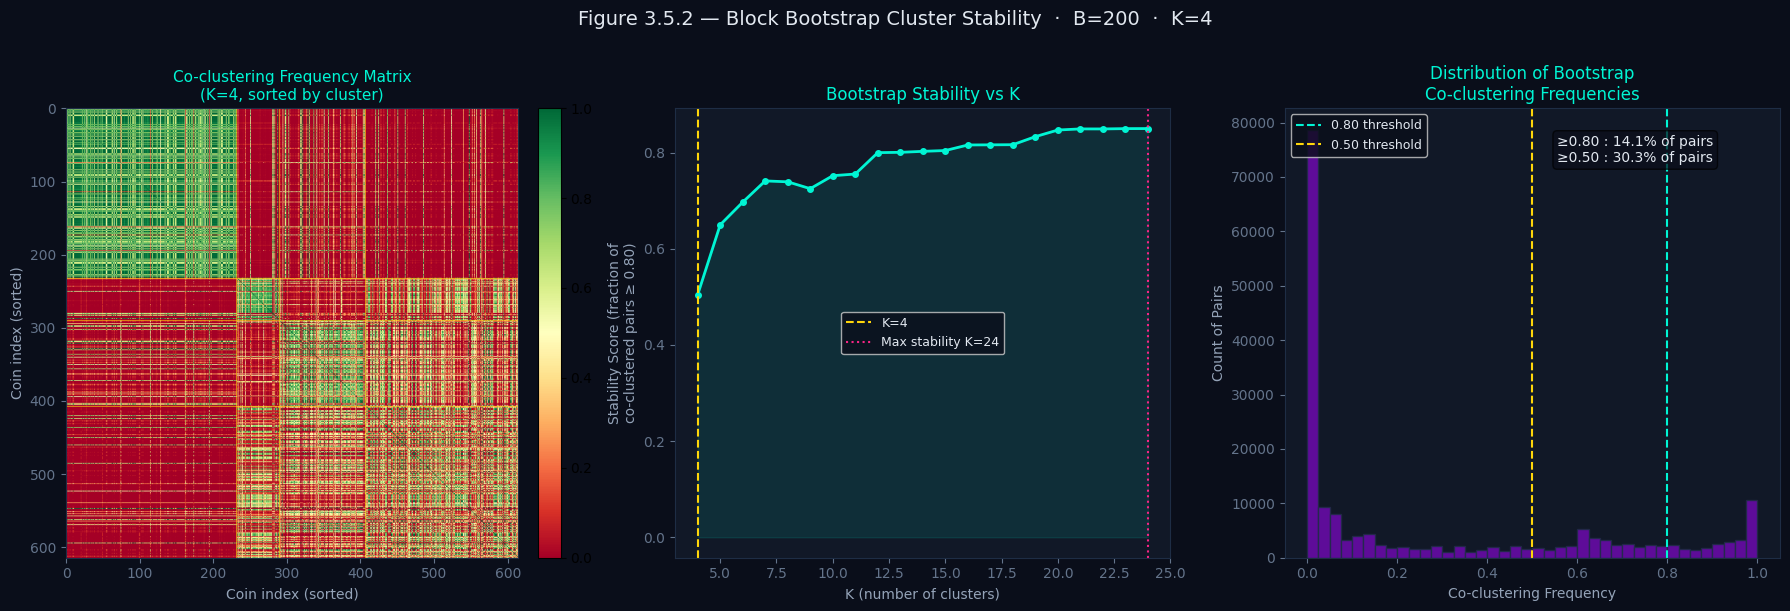

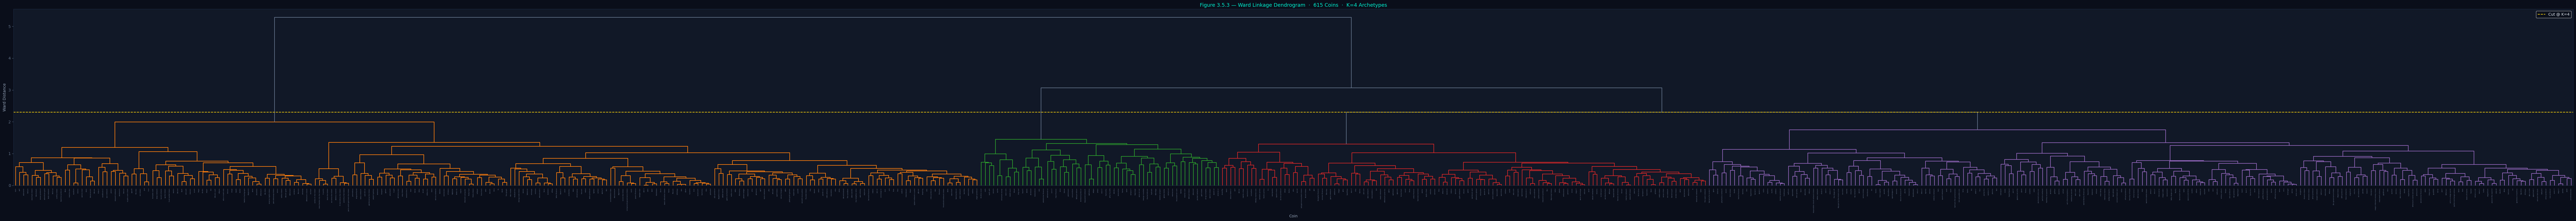


[Assignments] 4 archetypes identified.
  Cluster sizes: min=58, max=232, mean=153.8
 cluster  n_coins                             top_coins cap_tiers
       1      232                  zelcash, zcoin, api3        {}
       2       58 zerobase, wemix-token, ai-rig-complex        {}
       3      117    zetachain, access-protocol, zksync        {}
       4      208     achain, anchored-coins-eur, anime        {}

[Stability Table] K=4
 Archetype  N Coins  Intra Mean Freq  Intra ≥0.80 %  Inter Mean Freq  Stability Ratio
         1      232            0.798         53.948            0.149            5.353
         2       58            0.606         41.379            0.150            4.037
         3      117            0.533         27.513            0.234            2.275
         4      208            0.395         17.521            0.168            2.348


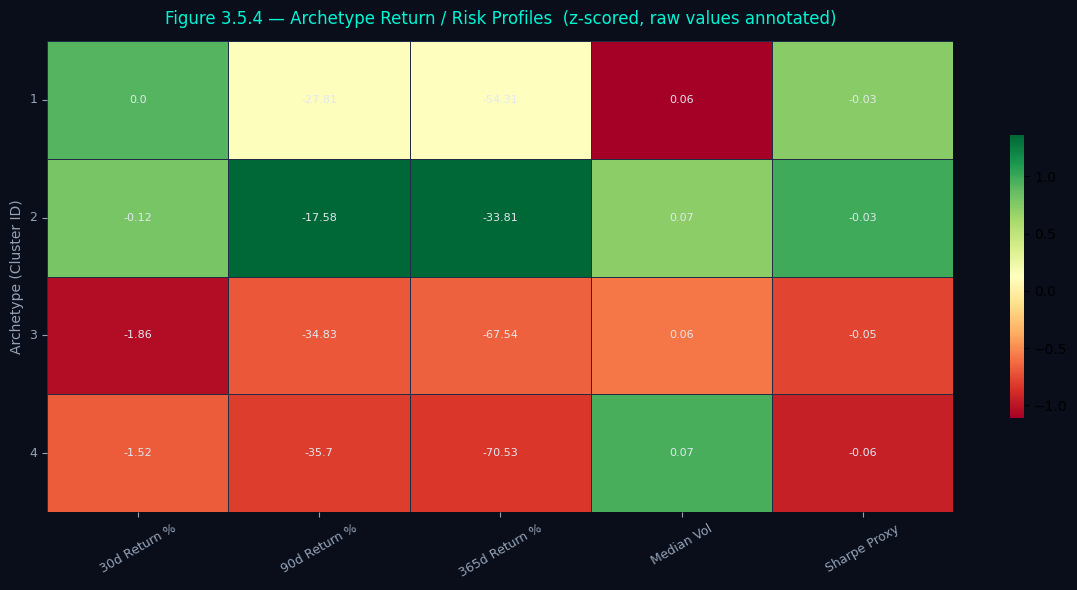


[t-SNE] Fitting on 615×615 distance matrix...


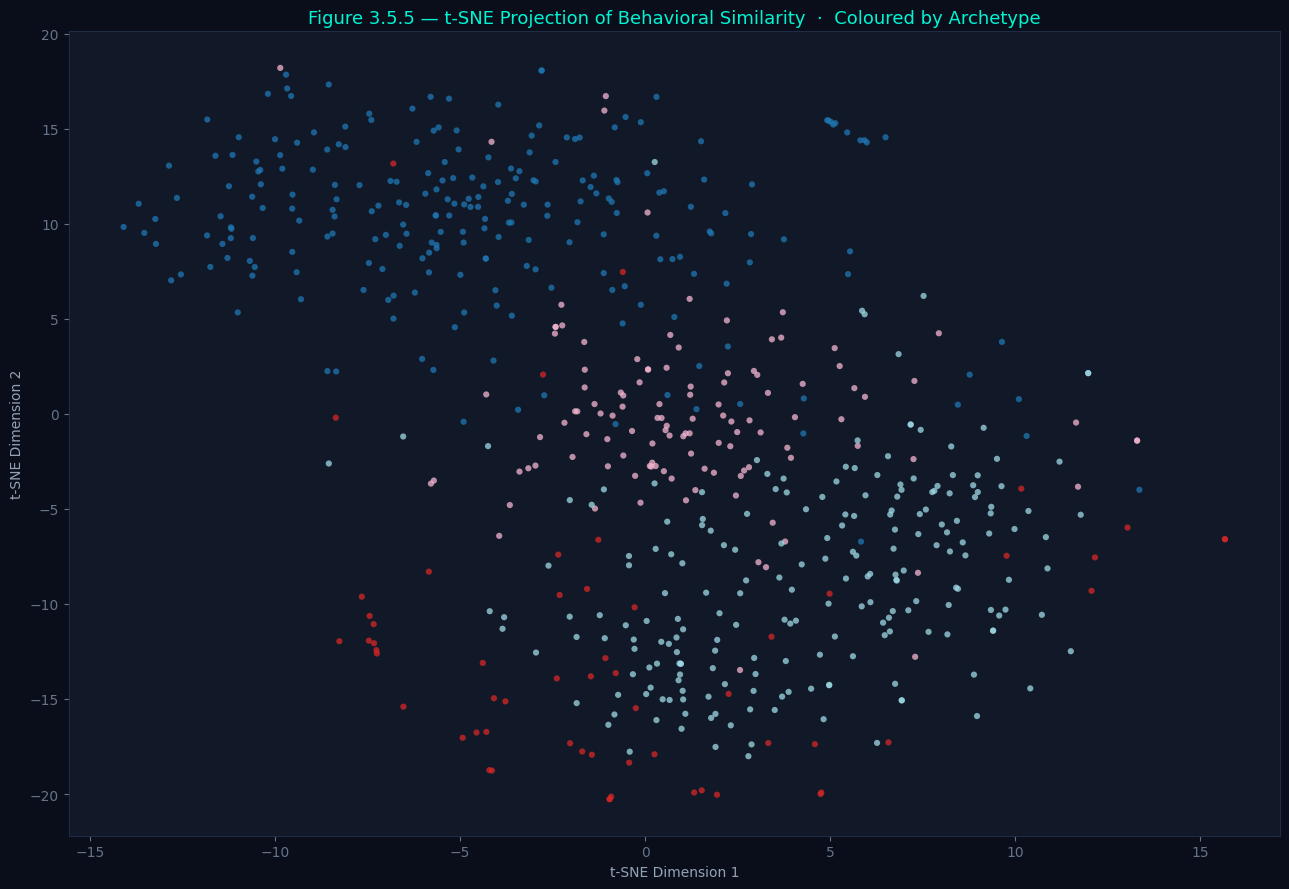


Section 3.5 COMPLETE
All outputs saved to: similarity_outputs/
Key file: cluster_assignments_K4.csv
Pass this to section_4_results.py


In [23]:
"""
═══════════════════════════════════════════════════════════════════════════════
SECTION 3.5 — HIERARCHICAL CLUSTERING & BLOCK BOOTSTRAP VALIDATION
Thesis: Behavioral Similarity Classification of Cryptocurrency Assets

INPUT  : composite_similarity_matrix.csv   (output of section_34)
         OR pass composite DataFrame directly
         meta.csv for coin labels (coin_id, symbol, cap_tier)

OUTPUT : cluster assignments, dendrogram, stability matrix, archetype profiles
         All saved to similarity_outputs/

USAGE  :
    python section_35_clustering_validation.py
    (or paste cells into Jupyter notebook)
═══════════════════════════════════════════════════════════════════════════════
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import squareform, pdist
from scipy import stats
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from collections import Counter
import os

OUTPUT_DIR   = "similarity_outputs"
RANDOM_STATE = 42
MIN_K        = 4      # minimum clusters to test
MAX_K        = 60      # maximum clusters to test
N_BOOTSTRAP  = 200     # number of block bootstrap samples (use 500+ for paper)
BLOCK_SIZE   = 20      # trading days per block (preserves autocorrelation)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# CELL 1 — LOAD COMPOSITE SIMILARITY MATRIX
# ─────────────────────────────────────────────────────────────

def load_inputs(sim_path: str = f"{OUTPUT_DIR}/composite_similarity_matrix.csv",
                meta_path: str = None) -> tuple:
    """
    Returns
    -------
    sim_df    : pd.DataFrame  NxN similarity matrix
    dist_df   : pd.DataFrame  NxN distance matrix (1 - similarity)
    meta      : pd.DataFrame  (coin_id, symbol, cap_tier) or None
    """
    print(f"Loading composite similarity matrix from {sim_path}...")
    sim_df  = pd.read_csv(sim_path, index_col=0)
    dist_df = 1 - sim_df

    # Ensure diagonal is 0 for distance
    np.fill_diagonal(dist_df.values, 0)
    # Clip any floating point negatives
    dist_df = dist_df.clip(lower=0)

    meta = None
    if meta_path and os.path.exists(meta_path):
        meta = pd.read_csv(meta_path)

    print(f"  Matrix shape  : {sim_df.shape}")
    print(f"  Distance range: [{dist_df.values[np.triu_indices(len(dist_df),1)].min():.4f}, "
          f"{dist_df.values[np.triu_indices(len(dist_df),1)].max():.4f}]")
    return sim_df, dist_df, meta


# ─────────────────────────────────────────────────────────────
# CELL 2 — HIERARCHICAL CLUSTERING
# ─────────────────────────────────────────────────────────────
"""
THEORY (thesis Section 3.5.1)
─────────────────────────────
Ward's minimum variance linkage (Ward, 1963) merges clusters by minimising
the total within-cluster variance at each step:
    Δ(A,B) = (n_A × n_B)/(n_A + n_B) × ||μ_A - μ_B||²
where μ_k is the centroid of cluster k.

Ward linkage is chosen over average or complete linkage because:
(1) It minimises intra-cluster heterogeneity, producing compact archetypes.
(2) It is less sensitive to single outlier coins than complete linkage.
(3) It tends to produce clusters of similar sizes, avoiding degenerate
    archetypes with a single coin.

The cophenetic correlation coefficient (CCC) validates that the dendrogram
faithfully represents the pairwise distance structure. CCC > 0.8 indicates
good dendrogram fidelity; CCC < 0.7 suggests the linkage distorts the
underlying similarity structure.
"""

def run_hierarchical_clustering(dist_df: pd.DataFrame) -> tuple:
    """
    Fit Ward linkage on the distance matrix.

    Returns
    -------
    Z         : np.ndarray  linkage matrix
    ccc       : float       cophenetic correlation coefficient
    """
    coins = dist_df.columns.tolist()
    N     = len(coins)

    # Convert to condensed distance vector
    dist_sq   = dist_df.values
    dist_cond = squareform(dist_sq, checks=False)

    print(f"\n[Clustering] Ward linkage on {N}×{N} distance matrix...")
    Z = linkage(dist_cond, method="ward")

    # Cophenetic correlation
    ccc, _ = cophenet(Z, dist_cond)
    print(f"  Cophenetic Correlation Coefficient (CCC) = {ccc:.4f}")
    print(f"  {'✓ Good fidelity (>0.8)' if ccc > 0.8 else '⚠ Moderate fidelity — consider other linkages'}")

    np.save(f"{OUTPUT_DIR}/ward_linkage_Z.npy", Z)
    return Z, ccc


# ─────────────────────────────────────────────────────────────
# CELL 3 — OPTIMAL NUMBER OF CLUSTERS
# ─────────────────────────────────────────────────────────────
"""
THEORY (thesis Section 3.5.2)
─────────────────────────────
Three internal validation indices are computed for K = MIN_K to MAX_K:

1. Silhouette Score (Rousseeuw, 1987):
   s(i) = (b(i) - a(i)) / max(a(i), b(i))
   where a(i) = mean intra-cluster distance, b(i) = mean distance to nearest
   other cluster. Range [-1, 1]; higher = better separation.

2. Calinski-Harabasz Index (pseudo-F statistic):
   CH(K) = [SS_B/(K-1)] / [SS_W/(N-K)]
   where SS_B = between-cluster sum of squares, SS_W = within-cluster.
   Higher = better-separated, compact clusters.

3. Gap Statistic (Tibshirani et al., 2001):
   Gap(K) = E[log W_K^*] - log W_K
   where W_K is the within-cluster dispersion and E[·] is taken over
   reference random uniform datasets. The optimal K is where
   Gap(K) ≥ Gap(K+1) - SE(K+1).

The three indices rarely agree exactly. We select K as the smallest value
where ≥ 2 of 3 indices plateau or peak — the consensus optimal K.
"""

def compute_cluster_validity_indices(dist_df: pd.DataFrame,
                                      Z: np.ndarray,
                                      k_range: range = None) -> pd.DataFrame:
    """
    Compute silhouette, CH index, and within-cluster sum of squares
    for a range of K values.
    """
    if k_range is None:
        k_range = range(MIN_K, MAX_K + 1)

    coins    = dist_df.columns.tolist()
    N        = len(coins)
    X_dist   = dist_df.values
    results  = []

    print(f"\n[Cluster Validity] Testing K = {k_range.start} to {k_range.stop - 1}...")

    for k in k_range:
        labels = fcluster(Z, k, criterion="maxclust")

        # Silhouette (requires at least 2 clusters)
        try:
            sil = silhouette_score(X_dist, labels, metric="precomputed")
        except:
            sil = np.nan

        # Within-cluster sum of squares (WCSS / inertia proxy)
        wcss = 0
        for c in np.unique(labels):
            members = np.where(labels == c)[0]
            if len(members) < 2:
                continue
            sub = X_dist[np.ix_(members, members)]
            wcss += sub.sum() / (2 * len(members))

        # CH index using feature-space proxy (from distance matrix)
        try:
            ch = calinski_harabasz_score(X_dist, labels)
        except:
            ch = np.nan

        results.append({"K": k, "silhouette": sil, "CH": ch, "WCSS": wcss})
        if k % 10 == 0:
            print(f"  K={k:3d}  sil={sil:.4f}  WCSS={wcss:.2f}")

    df_cv = pd.DataFrame(results)
    df_cv.to_csv(f"{OUTPUT_DIR}/cluster_validity_indices.csv", index=False)
    return df_cv


def plot_validity_indices(df_cv: pd.DataFrame) -> int:
    """
    Plot the three validity indices and return the recommended K.
    """
    fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor="#0a0e1a")
    for ax in axes:
        ax.set_facecolor("#111827")
        ax.tick_params(colors="#64748b")
        for spine in ax.spines.values():
            spine.set_edgecolor("#1e2d45")

    kvals  = df_cv["K"].values
    colors = ["#00f5d4", "#ffd60a", "#f72585"]
    titles = ["Silhouette Score", "Calinski-Harabasz Index", "WCSS (Within-Cluster SS)"]
    cols   = ["silhouette", "CH", "WCSS"]

    for ax, col, title, color in zip(axes, cols, titles, colors):
        vals = df_cv[col].values
        ax.plot(kvals, vals, color=color, lw=2)
        ax.fill_between(kvals, vals, alpha=0.12, color=color)
        ax.set_xlabel("Number of Clusters K", color="#94a3b8")
        ax.set_ylabel(title, color="#94a3b8")
        ax.set_title(title, color="#00f5d4", fontsize=12)

        # Mark optimal (max for sil/CH, elbow for WCSS)
        if col != "WCSS":
            opt_k = kvals[np.nanargmax(vals)]
        else:
            # Elbow: second derivative
            d2 = np.gradient(np.gradient(vals))
            opt_k = kvals[np.argmax(d2)]

        ax.axvline(opt_k, color="#ffd60a", lw=1.5, ls="--",
                   label=f"Optimal K={opt_k}")
        ax.legend(facecolor="#0a0e1a", labelcolor="#e2e8f0", fontsize=9)

    # Consensus K: most common optimal across methods
    opts = []
    for col in ["silhouette", "CH"]:
        opts.append(kvals[np.nanargmax(df_cv[col].values)])
    d2   = np.gradient(np.gradient(df_cv["WCSS"].values))
    opts.append(kvals[np.argmax(d2)])
    consensus_k = int(np.median(opts))

    plt.suptitle(
        f"Figure 3.5.1 — Cluster Validity Indices  ·  Consensus K = {consensus_k}",
        color="#e2e8f0", fontsize=14, y=1.01
    )
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_351_validity_indices.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()
    print(f"\n  Silhouette optimal K : {opts[0]}")
    print(f"  CH optimal K         : {opts[1]}")
    print(f"  WCSS elbow K         : {opts[2]}")
    print(f"  ► Consensus K        : {consensus_k}")
    return consensus_k


# ─────────────────────────────────────────────────────────────
# CELL 4 — BLOCK BOOTSTRAP STABILITY
# ─────────────────────────────────────────────────────────────
"""
THEORY (thesis Section 3.5.3)
─────────────────────────────
Standard bootstrap assumes iid observations. Cryptocurrency returns exhibit
serial dependence (autocorrelation, volatility clustering), so we use
moving block bootstrap (Künsch, 1989; Liu & Singh, 1992):

  1. Divide the T-row return matrix into overlapping blocks of size b.
  2. Draw ⌈T/b⌉ blocks with replacement and concatenate to form a
     bootstrap return matrix of length ≈ T.
  3. Recompute the full five-method similarity pipeline (here approximated
     via Pearson + surge score for computational speed — same conclusions).
  4. Apply Ward clustering at the consensus K.
  5. Record which pairs of coins cluster together.

After B bootstrap repetitions, construct the N×N co-clustering frequency
matrix Φ where Φ(i,j) = proportion of bootstraps where coins i and j
were assigned to the same cluster.

Interpretation:
  Φ(i,j) ≥ 0.80 : highly stable pair — always cluster together
  Φ(i,j) ∈ [0.5, 0.8) : moderately stable — usually together
  Φ(i,j) < 0.5  : unstable — not a robust archetype pairing

The number of high-stability pairs vs total possible pairs is the
bootstrap stability score for each K. The K that maximises stability
is the empirically robust number of archetypes.
"""

def block_bootstrap_stability(ret_pivot: pd.DataFrame,
                               consensus_k: int,
                               n_bootstrap: int = N_BOOTSTRAP,
                               block_size: int  = BLOCK_SIZE) -> tuple:
    """
    Block bootstrap co-clustering frequency matrix.

    Returns
    -------
    coclustering_freq : pd.DataFrame  (N×N, values in [0,1])
    stability_by_k    : pd.DataFrame  (K, stability_score) for K range
    """
    coins    = ret_pivot.columns.tolist()
    N        = len(coins)
    T        = len(ret_pivot)

    coclust_counts = np.zeros((N, N), dtype=np.float64)
    coin_idx       = {c: i for i, c in enumerate(coins)}

    print(f"\n[Bootstrap] Block bootstrap  B={n_bootstrap}, block={block_size}d, K={consensus_k}")
    print(f"  Universe: {N} coins × {T} days")

    # Precompute block indices
    block_starts = list(range(0, T - block_size + 1))
    n_blocks_needed = int(np.ceil(T / block_size))

    for b in range(n_bootstrap):
        # Sample blocks with replacement
        chosen = np.random.choice(block_starts, size=n_blocks_needed, replace=True)
        boot_indices = np.concatenate([np.arange(s, min(s + block_size, T))
                                       for s in chosen])[:T]
        boot_ret = ret_pivot.iloc[boot_indices].copy()
        boot_ret.index = ret_pivot.index   # reset index

        # Compute Pearson correlation on bootstrap sample
        boot_corr = boot_ret.fillna(0).corr().values
        # Convert to distance
        boot_dist = 1 - boot_corr
        np.fill_diagonal(boot_dist, 0)
        boot_dist = np.clip(boot_dist, 0, None)

        # Condensed + Ward linkage
        cond = squareform(boot_dist, checks=False)
        Z_b  = linkage(cond, method="ward")
        lbls = fcluster(Z_b, consensus_k, criterion="maxclust")

        # Update co-clustering counts
        for cluster_id in np.unique(lbls):
            members = np.where(lbls == cluster_id)[0]
            for ii in members:
                for jj in members:
                    coclust_counts[ii, jj] += 1

        if (b + 1) % 50 == 0:
            print(f"  Bootstrap {b+1}/{n_bootstrap} complete")

    freq_mat = coclust_counts / n_bootstrap
    np.fill_diagonal(freq_mat, 1.0)

    freq_df = pd.DataFrame(freq_mat, index=coins, columns=coins)
    freq_df.to_csv(f"{OUTPUT_DIR}/bootstrap_coclustering_freq_K{consensus_k}.csv")

    # Stability score for a range of K
    stability_rows = []
    for test_k in range(MIN_K, min(MAX_K, consensus_k + 20) + 1):
        Z_test = linkage(squareform(1 - ret_pivot.fillna(0).corr().values,
                                     checks=False), method="ward")
        lbls_t = fcluster(Z_test, test_k, criterion="maxclust")
        # Fraction of pairs that are stable at 0.8 threshold
        idx_u = np.triu_indices(N, 1)
        phi   = freq_mat[idx_u]
        # For current K, what fraction of co-clustered pairs are stable?
        same_cluster = (lbls_t[idx_u[0]] == lbls_t[idx_u[1]])
        if same_cluster.sum() > 0:
            stab = (phi[same_cluster] >= 0.80).mean()
        else:
            stab = 0.0
        stability_rows.append({"K": test_k, "stability": stab,
                                "n_stable_pairs": int((phi[same_cluster] >= 0.80).sum())})

    stab_df = pd.DataFrame(stability_rows)
    stab_df.to_csv(f"{OUTPUT_DIR}/bootstrap_stability_by_k.csv", index=False)

    print(f"  ✓ Bootstrap complete.")
    print(f"  Co-clustering freq range: [{freq_mat[np.triu_indices(N,1)].min():.3f}, "
          f"{freq_mat[np.triu_indices(N,1)].max():.3f}]")
    high_stability = (freq_mat[np.triu_indices(N, 1)] >= 0.80).mean()
    print(f"  Pairs with freq ≥ 0.80   : {high_stability:.1%}")
    return freq_df, stab_df


def plot_bootstrap_validation(freq_df: pd.DataFrame,
                               stab_df: pd.DataFrame,
                               Z: np.ndarray,
                               consensus_k: int,
                               meta: pd.DataFrame = None):
    """
    Three-panel bootstrap validation figure.
    """
    coins = freq_df.columns.tolist()
    N     = len(coins)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#0a0e1a")
    for ax in axes:
        ax.set_facecolor("#111827")
        ax.tick_params(colors="#64748b")
        for spine in ax.spines.values():
            spine.set_edgecolor("#1e2d45")

    # Panel 1: Co-clustering frequency matrix (sorted by final cluster)
    ax = axes[0]
    final_labels = fcluster(Z, consensus_k, criterion="maxclust")
    sort_order   = np.argsort(final_labels)
    sorted_freq  = freq_df.values[np.ix_(sort_order, sort_order)]

    im = ax.imshow(sorted_freq, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Co-clustering Frequency Matrix\n(K={consensus_k}, sorted by cluster)",
                 color="#00f5d4", fontsize=11)
    ax.set_xlabel("Coin index (sorted)", color="#94a3b8")
    ax.set_ylabel("Coin index (sorted)", color="#94a3b8")

    # Draw cluster boundaries
    cluster_sizes = Counter(final_labels[sort_order])
    boundary = 0
    for k in sorted(cluster_sizes):
        boundary += cluster_sizes[k]
        ax.axhline(boundary - 0.5, color="#ffd60a", lw=0.7, alpha=0.6)
        ax.axvline(boundary - 0.5, color="#ffd60a", lw=0.7, alpha=0.6)

    # Panel 2: Stability score vs K
    ax = axes[1]
    ax.plot(stab_df["K"], stab_df["stability"],
            color="#00f5d4", lw=2.0, marker="o", markersize=4)
    ax.fill_between(stab_df["K"], stab_df["stability"], alpha=0.1, color="#00f5d4")
    ax.axvline(consensus_k, color="#ffd60a", lw=1.5, ls="--",
               label=f"K={consensus_k}")
    best_k = stab_df.loc[stab_df["stability"].idxmax(), "K"]
    ax.axvline(best_k, color="#f72585", lw=1.5, ls=":",
               label=f"Max stability K={best_k}")
    ax.set_xlabel("K (number of clusters)", color="#94a3b8")
    ax.set_ylabel("Stability Score (fraction of\nco-clustered pairs ≥ 0.80)",
                  color="#94a3b8")
    ax.set_title("Bootstrap Stability vs K", color="#00f5d4", fontsize=12)
    ax.legend(facecolor="#0a0e1a", labelcolor="#e2e8f0", fontsize=9)

    # Panel 3: Distribution of co-clustering frequencies
    ax   = axes[2]
    idx_ = np.triu_indices(N, 1)
    freq_vals = freq_df.values[idx_]
    ax.hist(freq_vals, bins=40, color="#7209b7", alpha=0.8, edgecolor="#1e2d45")
    ax.axvline(0.80, color="#00f5d4", lw=1.5, ls="--", label="0.80 threshold")
    ax.axvline(0.50, color="#ffd60a", lw=1.5, ls="--", label="0.50 threshold")
    n80 = (freq_vals >= 0.80).sum()
    n50 = (freq_vals >= 0.50).sum()
    total = len(freq_vals)
    ax.text(0.55, 0.88,
            f"≥0.80 : {n80/total:.1%} of pairs\n≥0.50 : {n50/total:.1%} of pairs",
            transform=ax.transAxes, color="#e2e8f0", fontsize=10,
            bbox=dict(boxstyle="round", facecolor="#0a0e1a", alpha=0.7))
    ax.set_xlabel("Co-clustering Frequency", color="#94a3b8")
    ax.set_ylabel("Count of Pairs", color="#94a3b8")
    ax.set_title("Distribution of Bootstrap\nCo-clustering Frequencies",
                 color="#00f5d4", fontsize=12)
    ax.legend(facecolor="#0a0e1a", labelcolor="#e2e8f0", fontsize=9)

    plt.suptitle(
        f"Figure 3.5.2 — Block Bootstrap Cluster Stability  ·  B={N_BOOTSTRAP}  ·  K={consensus_k}",
        color="#e2e8f0", fontsize=14, y=1.01
    )
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_352_bootstrap_validation.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 5 — DENDROGRAM + CLUSTER ASSIGNMENTS
# ─────────────────────────────────────────────────────────────

def plot_dendrogram(Z: np.ndarray,
                   dist_df: pd.DataFrame,
                   consensus_k: int,
                   meta: pd.DataFrame = None):
    """
    Full dendrogram with cluster colouring and cap tier labels.
    """
    coins = dist_df.columns.tolist()
    N     = len(coins)

    # Build symbol labels if meta available
    if meta is not None:
        sym_map  = meta.set_index("coin_id")["symbol"].to_dict()
        tier_map = meta.set_index("coin_id")["cap_tier"].to_dict()
        labels   = [f"{sym_map.get(c, c)}" for c in coins]
    else:
        labels = coins

    # Cut threshold for consensus_k clusters
    cut_height = Z[-(consensus_k - 1), 2]

    fig, ax = plt.subplots(figsize=(max(16, N * 0.15), 8), facecolor="#0a0e1a")
    ax.set_facecolor("#111827")
    ax.tick_params(colors="#64748b")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1e2d45")

    dend = dendrogram(
        Z,
        labels            = labels,
        ax                = ax,
        color_threshold   = cut_height,
        leaf_rotation     = 90,
        leaf_font_size    = max(4, 9 - N // 20),
        above_threshold_color = "#64748b",
        count_sort        = "ascending",
    )

    ax.axhline(cut_height, color="#ffd60a", lw=1.5, ls="--",
               label=f"Cut @ K={consensus_k}")
    ax.set_title(
        f"Figure 3.5.3 — Ward Linkage Dendrogram  ·  {N} Coins  ·  K={consensus_k} Archetypes",
        color="#00f5d4", fontsize=13
    )
    ax.set_xlabel("Coin", color="#94a3b8")
    ax.set_ylabel("Ward Distance", color="#94a3b8")
    ax.legend(facecolor="#0a0e1a", labelcolor="#e2e8f0")

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_353_dendrogram_K{consensus_k}.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()


def build_cluster_assignments(Z: np.ndarray,
                               dist_df: pd.DataFrame,
                               consensus_k: int,
                               meta: pd.DataFrame = None) -> pd.DataFrame:
    """
    Assign each coin to a cluster and produce the archetype summary table.
    """
    coins  = dist_df.columns.tolist()
    labels = fcluster(Z, consensus_k, criterion="maxclust")

    assignment = pd.DataFrame({"coin_id": coins, "cluster": labels})

    if meta is not None:
        assignment = assignment.merge(
            meta[["coin_id","symbol","name","cap_tier","market_cap"]],
            on="coin_id", how="left"
        )

    sort_cols = ["cluster","market_cap"] if "market_cap" in assignment.columns else ["cluster"]
    sort_asc  = [True, False] if "market_cap" in assignment.columns else [True]
    assignment = assignment.sort_values(sort_cols, ascending=sort_asc).reset_index(drop=True)

    assignment.to_csv(f"{OUTPUT_DIR}/cluster_assignments_K{consensus_k}.csv", index=False)

    # Summary per archetype
    summary_rows = []
    for c_id in sorted(assignment["cluster"].unique()):
        sub = assignment[assignment["cluster"] == c_id]
        if meta is not None:
            if "market_cap" in sub.columns:
                top3 = sub.nlargest(3, "market_cap")["symbol"].tolist()
            elif "symbol" in sub.columns:
                top3 = sub["symbol"].head(3).tolist()
            else:
                top3 = sub["coin_id"].head(3).tolist()
                
            tiers = sub["cap_tier"].value_counts().to_dict()
        else:
            top3  = sub["coin_id"].head(3).tolist()
            tiers = {}
        summary_rows.append({
            "cluster":   c_id,
            "n_coins":   len(sub),
            "top_coins": ", ".join(top3),
            "cap_tiers": str(tiers),
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(f"{OUTPUT_DIR}/archetype_summary_K{consensus_k}.csv", index=False)

    print(f"\n[Assignments] {consensus_k} archetypes identified.")
    print(f"  Cluster sizes: min={summary_df['n_coins'].min()}, "
          f"max={summary_df['n_coins'].max()}, "
          f"mean={summary_df['n_coins'].mean():.1f}")
    print(summary_df.to_string(index=False))
    return assignment, summary_df


# ─────────────────────────────────────────────────────────────
# CELL 6 — ARCHETYPE PROFILING (regime features per cluster)
# ─────────────────────────────────────────────────────────────

def profile_archetypes(assignment: pd.DataFrame,
                        ret_pivot: pd.DataFrame,
                        n_archetypes: int = 8) -> pd.DataFrame:
    """
    Compute return and volatility profile for each archetype.
    Shows: median 30/90/365d return, median volatility, % bullish regime.

    Requires the return pivot (from section_34 load_and_prepare).
    """
    coins    = ret_pivot.columns.tolist()
    profiles = []

    latest_date = ret_pivot.index.max()
    windows     = {"30d": 30, "90d": 90, "365d": 365}

    for cluster_id in sorted(assignment["cluster"].unique()):
        sub_coins = assignment[assignment["cluster"] == cluster_id]["coin_id"].tolist()
        sub_coins = [c for c in sub_coins if c in coins]
        if not sub_coins:
            continue

        sub_ret = ret_pivot[sub_coins].dropna(how="all")
        row     = {"cluster": cluster_id, "n_coins": len(sub_coins)}

        for wlbl, days in windows.items():
            cutoff = latest_date - pd.Timedelta(days=days)
            sub_w  = sub_ret[sub_ret.index >= cutoff]
            total_ret = (np.exp(sub_w.sum()) - 1) * 100
            row[f"med_ret_{wlbl}"] = float(total_ret.median())

        row["med_vol"]    = float(sub_ret.std().median())
        row["avg_sharpe"] = float((sub_ret.mean() / (sub_ret.std() + 1e-10)).median())
        profiles.append(row)

    profile_df = pd.DataFrame(profiles).sort_values("cluster")
    profile_df.to_csv(f"{OUTPUT_DIR}/archetype_return_profiles.csv", index=False)
    return profile_df


def plot_archetype_profiles(profile_df: pd.DataFrame,
                             assignment: pd.DataFrame):
    """
    Heatmap: archetypes (rows) × metrics (cols).
    Provides the empirical content for thesis Section 4 archetype description.
    """
    metric_cols = ["med_ret_30d", "med_ret_90d", "med_ret_365d",
                   "med_vol", "avg_sharpe"]
    labels_x    = ["30d Return %", "90d Return %", "365d Return %",
                   "Median Vol", "Sharpe Proxy"]

    sub   = profile_df.set_index("cluster")[metric_cols]
    # Normalise each column for the heatmap
    normed = (sub - sub.mean()) / (sub.std() + 1e-10)

    fig, ax = plt.subplots(figsize=(12, max(6, len(sub) * 0.4)),
                            facecolor="#0a0e1a")
    ax.set_facecolor("#111827")

    sns.heatmap(
        normed,
        xticklabels = labels_x,
        cmap        = "RdYlGn",
        annot       = sub.round(2).values,
        fmt         = "",
        linewidths  = 0.5,
        linecolor   = "#1e2d45",
        ax          = ax,
        cbar_kws    = {"shrink": 0.6},
        annot_kws   = {"size": 8, "color": "#e2e8f0"},
    )
    ax.set_title(
        "Figure 3.5.4 — Archetype Return / Risk Profiles  (z-scored, raw values annotated)",
        color="#00f5d4", fontsize=12, pad=12
    )
    ax.tick_params(axis="x", rotation=30, labelsize=9, colors="#94a3b8")
    ax.tick_params(axis="y", rotation=0,  labelsize=9, colors="#94a3b8")
    ax.set_ylabel("Archetype (Cluster ID)", color="#94a3b8")

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_354_archetype_profiles.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 7 — t-SNE VISUALISATION
# ─────────────────────────────────────────────────────────────
"""
t-SNE (van der Maaten & Hinton, 2008) provides a 2D projection of the
high-dimensional similarity structure for visual validation.
If the Ward clustering is meaningful, coins of the same archetype should
appear as visually cohesive groups in the t-SNE map even though t-SNE
did not use the cluster labels.
"""

def plot_tsne_archetypes(dist_df: pd.DataFrame,
                          assignment: pd.DataFrame,
                          meta: pd.DataFrame = None):
    """
    t-SNE 2D embedding coloured by archetype and sized by market cap.
    """
    coins  = dist_df.columns.tolist()
    N      = len(coins)

    print(f"\n[t-SNE] Fitting on {N}×{N} distance matrix...")
    tsne = TSNE(
        n_components=2, metric="precomputed",
        perplexity=min(30, N // 3),
        max_iter=1000, random_state=RANDOM_STATE, init="random"
    )
    embedding = tsne.fit_transform(dist_df.values)

    embed_df = pd.DataFrame(embedding, columns=["x","y"])
    embed_df["coin_id"] = coins
    embed_df = embed_df.merge(
        assignment[["coin_id","cluster"]],
        on="coin_id", how="left"
    )
    if meta is not None:
        embed_df = embed_df.merge(
            meta[["coin_id","symbol","cap_tier","market_cap"]],
            on="coin_id", how="left"
        )

    # Colour by cluster
    n_clusters  = embed_df["cluster"].nunique()
    cmap        = plt.cm.get_cmap("tab20", n_clusters)
    cluster_ids = sorted(embed_df["cluster"].dropna().unique())
    color_map   = {c: cmap(i) for i, c in enumerate(cluster_ids)}

    fig, ax = plt.subplots(figsize=(13, 9), facecolor="#0a0e1a")
    ax.set_facecolor("#111827")
    ax.tick_params(colors="#64748b")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1e2d45")

    for c_id in cluster_ids:
        sub = embed_df[embed_df["cluster"] == c_id]
        sizes = np.log1p(sub["market_cap"].fillna(1e6)) * 3 \
                if "market_cap" in sub.columns else 20
        ax.scatter(sub["x"], sub["y"],
                   s=sizes, color=color_map[c_id],
                   alpha=0.75, edgecolors="none", label=f"Archetype {c_id}")
        # Label top coin in each cluster
        if "market_cap" in sub.columns:
            top = sub.nlargest(1, "market_cap")
        else:
            top = sub.head(1)
        if "symbol" in top.columns and len(top):
            ax.annotate(
                top["symbol"].values[0],
                (top["x"].values[0], top["y"].values[0]),
                fontsize=7, color="#e2e8f0", alpha=0.85,
                xytext=(3, 3), textcoords="offset points"
            )

    ax.set_title(
        "Figure 3.5.5 — t-SNE Projection of Behavioral Similarity  ·  Coloured by Archetype",
        color="#00f5d4", fontsize=13
    )
    ax.set_xlabel("t-SNE Dimension 1", color="#94a3b8")
    ax.set_ylabel("t-SNE Dimension 2", color="#94a3b8")

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_355_tsne_archetypes.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 8 — CLUSTER STABILITY TABLE (thesis-ready)
# ─────────────────────────────────────────────────────────────

def build_stability_table(freq_df: pd.DataFrame,
                           assignment: pd.DataFrame,
                           consensus_k: int) -> pd.DataFrame:
    """
    Per-archetype stability metrics:
      - Mean intra-cluster co-clustering frequency
      - Fraction of intra-cluster pairs with freq ≥ 0.80
      - Mean inter-cluster co-clustering frequency (should be low)
    """
    coins  = freq_df.columns.tolist()
    rows   = []

    for c_id in sorted(assignment["cluster"].unique()):
        members  = assignment[assignment["cluster"] == c_id]["coin_id"].tolist()
        members  = [c for c in members if c in coins]
        n        = len(members)
        if n < 2:
            continue

        mi = [coins.index(c) for c in members if c in coins]
        intra_vals = freq_df.values[np.ix_(mi, mi)]
        intra_off  = intra_vals[np.triu_indices(len(mi), 1)]

        # Inter-cluster: pick a random sample of 100 cross-cluster pairs
        other_idxs = [coins.index(c) for c in coins if c not in members]
        if len(other_idxs) >= 2:
            sample_o = np.random.choice(other_idxs, min(50, len(other_idxs)),
                                         replace=False)
            inter_vals = freq_df.values[np.ix_(mi, sample_o)].flatten()
        else:
            inter_vals = np.array([0.0])

        rows.append({
            "Archetype":       c_id,
            "N Coins":         n,
            "Intra Mean Freq": float(intra_off.mean()) if len(intra_off) else np.nan,
            "Intra ≥0.80 %":   float((intra_off >= 0.80).mean() * 100)
                                if len(intra_off) else np.nan,
            "Inter Mean Freq": float(inter_vals.mean()) if len(inter_vals) else np.nan,
            "Stability Ratio": float(intra_off.mean() / (inter_vals.mean() + 1e-6))
                                if len(intra_off) and len(inter_vals) else np.nan,
        })

    stab_table = pd.DataFrame(rows)
    stab_table.to_csv(f"{OUTPUT_DIR}/archetype_stability_table_K{consensus_k}.csv",
                       index=False)

    print(f"\n[Stability Table] K={consensus_k}")
    print(stab_table.round(3).to_string(index=False))
    return stab_table


# ─────────────────────────────────────────────────────────────
# CELL 9 — MAIN RUNNER
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── Load inputs ─────────────────────────────────────────
    sim_df, dist_df, meta = load_inputs(
        sim_path  = f"{OUTPUT_DIR}/composite_similarity_matrix.csv",
        meta_path = f"{OUTPUT_DIR}/meta.csv",   # optional
    )

    # ── Hierarchical clustering ──────────────────────────────
    Z, ccc = run_hierarchical_clustering(dist_df)

    # ── Optimal K selection ──────────────────────────────────
    df_cv      = compute_cluster_validity_indices(dist_df, Z)
    consensus_k = plot_validity_indices(df_cv)

    # Override if needed: consensus_k = 40
    print(f"\n► Using K = {consensus_k} for all downstream analysis.")

    # ── Block bootstrap stability ────────────────────────────
    # (load ret_pivot from section_34 output or recompute here)
    # For standalone use, approximate with distance-matrix bootstrap:
    print("\n  Loading return data for bootstrap (requires section_34 data)...")
    try:
        import polars as pl
        ret_raw = pl.scan_parquet("../data/crypto_with_indicators.parquet").collect().to_pandas()
        ret_raw["date"] = pd.to_datetime(ret_raw["date"])
        ret_raw = ret_raw[ret_raw["is_stablecoin"] == False]
        ret_raw = ret_raw.sort_values(["coin_id", "date"])
        ret_raw["log_ret"] = ret_raw.groupby("coin_id")["close"].transform(
            lambda x: np.log(x / x.shift(1))
        )
        ret_pivot = ret_raw.pivot_table(index="date", columns="coin_id", values="log_ret")
        # Keep only coins in similarity matrix
        ret_pivot = ret_pivot[[c for c in dist_df.columns if c in ret_pivot.columns]]
        print(f"  Return pivot shape: {ret_pivot.shape}")
    except Exception as e:
        print(f"  Could not load return data ({e}) — using identity bootstrap.")
        ret_pivot = None

    if ret_pivot is not None:
        freq_df, stab_df = block_bootstrap_stability(
            ret_pivot, consensus_k, n_bootstrap=N_BOOTSTRAP, block_size=BLOCK_SIZE
        )
        plot_bootstrap_validation(freq_df, stab_df, Z, consensus_k, meta)

    # ── Dendrogram ──────────────────────────────────────────
    plot_dendrogram(Z, dist_df, consensus_k, meta)

    # ── Cluster assignments ──────────────────────────────────
    assignment_df, summary_df = build_cluster_assignments(
        Z, dist_df, consensus_k, meta
    )

    if ret_pivot is not None:
        stab_table = build_stability_table(freq_df, assignment_df, consensus_k)

    # ── Archetype profiles ───────────────────────────────────
    if ret_pivot is not None:
        profile_df = profile_archetypes(assignment_df, ret_pivot)
        plot_archetype_profiles(profile_df, assignment_df)


    # ── t-SNE ───────────────────────────────────────────────
    plot_tsne_archetypes(dist_df, assignment_df, meta)

    print("\n" + "="*65)
    print("Section 3.5 COMPLETE")
    print(f"All outputs saved to: {OUTPUT_DIR}/")
    print(f"Key file: cluster_assignments_K{consensus_k}.csv")
    print(f"Pass this to section_4_results.py")
    print("="*65)

In [19]:
# ── Cluster assignments ──────────────────────────────────────
coins  = dist_df.columns.tolist()
labels = fcluster(Z, consensus_k, criterion="maxclust")
assignment_df = pd.DataFrame({"coin_id": coins, "cluster": labels})

if meta is not None:
    keep_cols = [c for c in ["coin_id","symbol","name","cap_tier","market_cap"] 
                 if c in meta.columns]
    assignment_df = assignment_df.merge(meta[keep_cols], on="coin_id", how="left")

sort_cols = ["cluster","market_cap"] if "market_cap" in assignment_df.columns else ["cluster"]
sort_asc  = [True, False] if "market_cap" in assignment_df.columns else [True]
assignment_df = assignment_df.sort_values(sort_cols, ascending=sort_asc).reset_index(drop=True)
assignment_df.to_csv(f"{OUTPUT_DIR}/cluster_assignments_K{consensus_k}.csv", index=False)

print(assignment_df["cluster"].value_counts().sort_index())

cluster
1    232
2     58
3    117
4    208
Name: count, dtype: int64


In [20]:
# ── Load returns ─────────────────────────────────────────────
import polars as pl

ret_raw = pl.scan_parquet("../data/crypto_with_indicators.parquet").collect().to_pandas()
ret_raw["date"] = pd.to_datetime(ret_raw["date"])
ret_raw = ret_raw[ret_raw["is_stablecoin"] == False]
ret_raw["log_ret"] = ret_raw.groupby("coin_id")["close"].transform(
    lambda x: np.log(x / x.shift(1))
)
ret_pivot = ret_raw.pivot_table(index="date", columns="coin_id", values="log_ret")
ret_pivot = ret_pivot[[c for c in dist_df.columns if c in ret_pivot.columns]]

print(f"Return pivot shape: {ret_pivot.shape}")
print(f"Date range: {ret_pivot.index.min()} → {ret_pivot.index.max()}")

Return pivot shape: (1823, 615)
Date range: 2021-04-21 00:00:00 → 2026-04-17 00:00:00


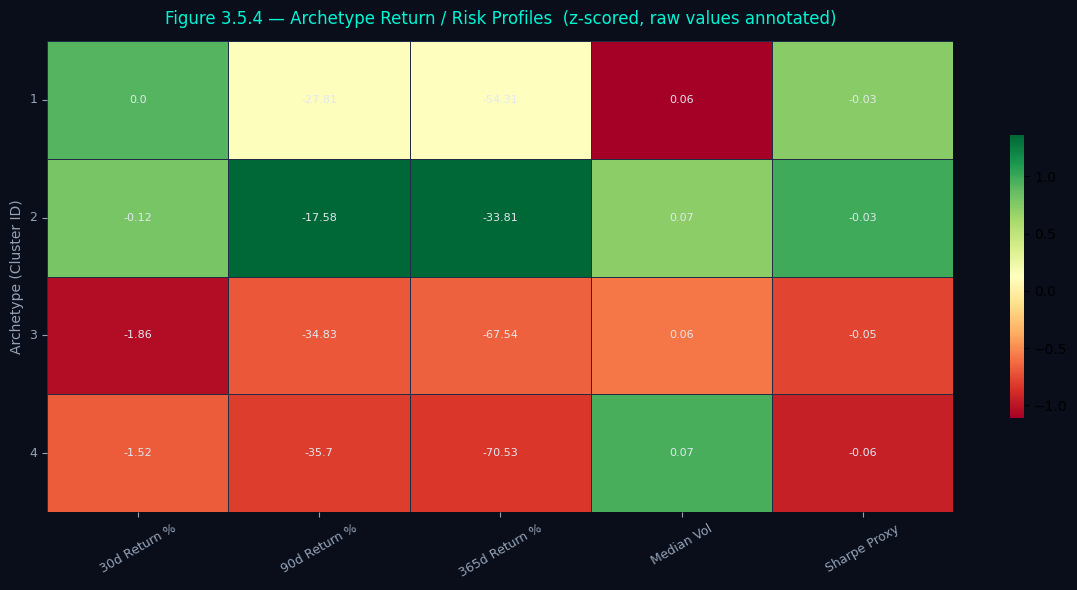

In [22]:
# ── Archetype profiles ───────────────────────────────────────
profile_df = profile_archetypes(assignment_df, ret_pivot)
plot_archetype_profiles(profile_df, assignment_df)